TRABAJO: **Análisis multivariante del bienestar psicológico en población joven**


ASIGNATURA: Análisis, Monitorización y Diagnóstico de Procesos Multivariantes


INTEGRANTES: **Patricia Rodrigo Barrio y Víctor Rodríguez Albendea**


El siguiente código se empleó para desarrollar el análisis exploratorio mediante K-means aplicado al bloque de hábitos de vida. En él se evaluaron distintas soluciones de agrupamiento y se examinó en qué medida los clusters obtenidos se alineaban con la estructura previamente identificada mediante PCA y con diferentes niveles de Anxiety_Score.

In [ ]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler


# CONFIGURACIÓN
FILE_PATH = Path(r"C:\Users\USUARIO\Downloads\Trabajo MOD\GenZ_dataset_con_low.xlsx")
SHEET_NAME = 0

X_COLS = [
    "Daily_Social_Media_Hours",
    "Screen_Time_Hours",
    "Night_Scrolling_Frequency",
    "Online_Gaming_Hours",
    "Exercise_Frequency_per_Week",
    "Daily_Sleep_Hours",
    "Caffeine_Intake_Cups",
    "Study_Work_Hours_per_Day",
]

N_COMPONENTS = 4
CV_FOLDS = 5
RANDOM_STATE = 42

OUT_DIR = Path("PCA_dragonet_replica")
OUT_DIR.mkdir(exist_ok=True)

# Reglas para orientar los signos y que el gráfico se parezca más a Dragonet
# (cambiar el signo de una CP no altera el PCA, solo la orientación visual)
SIGN_RULES = {
    0: ("Daily_Social_Media_Hours", +1),   # PC1
    1: ("Daily_Sleep_Hours", -1),          # PC2
    2: ("Daily_Sleep_Hours", +1),          # PC3
    3: ("Online_Gaming_Hours", +1),        # PC4
}

# UTILIDADES
def validate_columns(df: pd.DataFrame, cols: list[str]) -> None:
    missing = [c for c in cols if c not in df.columns]
    if missing:
        raise ValueError(f"Faltan columnas en el archivo: {missing}")


def orient_components(
    scores: np.ndarray,
    components: np.ndarray,
    loadings: np.ndarray,
    variable_names: list[str],
    sign_rules: dict[int, tuple[str, int]],
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Ajusta el signo de scores/components/loadings para parecerse más a Dragonet.
    """
    scores = scores.copy()
    components = components.copy()
    loadings = loadings.copy()

    var_to_idx = {v: i for i, v in enumerate(variable_names)}

    for comp_idx, (var_name, desired_sign) in sign_rules.items():
        if comp_idx >= components.shape[0]:
            continue
        if var_name not in var_to_idx:
            continue

        j = var_to_idx[var_name]
        current = np.sign(loadings[j, comp_idx])

        if current == 0:
            continue

        if current != desired_sign:
            scores[:, comp_idx] *= -1
            components[comp_idx, :] *= -1
            loadings[:, comp_idx] *= -1

    return scores, components, loadings


def compute_r2x_variablewise(
    x_scaled: np.ndarray,
    pca_model: PCA,
    max_components: int,
) -> pd.DataFrame:
    """
    R2X acumulado por variable y por número de componentes.
    """
    n_vars = x_scaled.shape[1]
    tss_var = np.sum(x_scaled ** 2, axis=0)

    out = np.zeros((n_vars, max_components), dtype=float)

    for a in range(1, max_components + 1):
        scores_a = pca_model.transform(x_scaled)[:, :a]
        x_hat = scores_a @ pca_model.components_[:a, :]
        sse_var = np.sum((x_scaled - x_hat) ** 2, axis=0)
        out[:, a - 1] = 1.0 - (sse_var / tss_var)

    cols = [f"LV{i}" for i in range(1, max_components + 1)]
    return pd.DataFrame(out, columns=cols)


def compute_q2x_cv(
    x_raw: np.ndarray,
    n_components: int,
    n_splits: int = 5,
    random_state: int = 42,
) -> tuple[np.ndarray, pd.DataFrame]:
    """
    Aproximación de Q2X acumulado por validación cruzada.
    Se hace fold a fold con escalado dentro de cada fold.
    """
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    q2x_cum = np.zeros(n_components, dtype=float)
    press_var_all = np.zeros((n_components, x_raw.shape[1]), dtype=float)
    tss_var_all = np.zeros((n_components, x_raw.shape[1]), dtype=float)

    for a in range(1, n_components + 1):
        press_total = 0.0
        tss_total = 0.0

        press_var = np.zeros(x_raw.shape[1], dtype=float)
        tss_var = np.zeros(x_raw.shape[1], dtype=float)

        for train_idx, test_idx in kf.split(x_raw):
            x_train = x_raw[train_idx]
            x_test = x_raw[test_idx]

            scaler = StandardScaler(with_mean=True, with_std=True)
            x_train_sc = scaler.fit_transform(x_train)
            x_test_sc = scaler.transform(x_test)

            pca = PCA(n_components=a, svd_solver="full")
            pca.fit(x_train_sc)

            scores_test = pca.transform(x_test_sc)
            x_hat_test = pca.inverse_transform(scores_test)

            residuals = x_test_sc - x_hat_test

            press_total += np.sum(residuals ** 2)
            tss_total += np.sum(x_test_sc ** 2)

            press_var += np.sum(residuals ** 2, axis=0)
            tss_var += np.sum(x_test_sc ** 2, axis=0)

        q2x_cum[a - 1] = 1.0 - (press_total / tss_total)
        press_var_all[a - 1, :] = press_var
        tss_var_all[a - 1, :] = tss_var

    q2x_var = 1.0 - (press_var_all / tss_var_all)
    q2x_var_df = pd.DataFrame(
        q2x_var.T,
        columns=[f"LV{i}" for i in range(1, n_components + 1)],
    )

    return q2x_cum, q2x_var_df


def plot_r2q2(r2x_cum: np.ndarray, q2x_cum: np.ndarray, out_path: Path) -> None:
    x = np.arange(1, len(r2x_cum) + 1)

    plt.figure(figsize=(7, 5))
    width = 0.35
    plt.bar(x - width / 2, r2x_cum, width=width, label=r"$R_X^2$")
    plt.bar(x + width / 2, q2x_cum, width=width, label=r"$Q_X^2$")
    plt.ylim(0, 1)
    plt.xlabel("Components")
    plt.ylabel(r"$R_X^2$ and $Q_X^2$ cumulative")
    plt.xticks(x)
    plt.legend()
    plt.tight_layout()
    plt.savefig(out_path, dpi=300)
    plt.close()


def plot_loading(
    loadings_df: pd.DataFrame,
    comp_x: int,
    comp_y: int,
    out_path: Path,
) -> None:
    plt.figure(figsize=(7, 6))
    x = loadings_df[f"PC{comp_x}"].values
    y = loadings_df[f"PC{comp_y}"].values

    plt.scatter(x, y)
    for xi, yi, label in zip(x, y, loadings_df["Variable"]):
        plt.text(xi, yi, label, fontsize=9)

    plt.axhline(0, linewidth=0.8)
    plt.axvline(0, linewidth=0.8)
    plt.xlabel(f"{comp_x} PCA component")
    plt.ylabel(f"{comp_y} PCA component")
    plt.tight_layout()
    plt.savefig(out_path, dpi=300)
    plt.close()


def plot_scores(
    scores_df: pd.DataFrame,
    comp_x: int,
    comp_y: int,
    out_path: Path,
) -> None:
    plt.figure(figsize=(7, 6))
    plt.scatter(
        scores_df[f"PC{comp_x}"],
        scores_df[f"PC{comp_y}"],
        alpha=0.5,
    )
    plt.axhline(0, linewidth=0.8)
    plt.axvline(0, linewidth=0.8)
    plt.xlabel(f"{comp_x} PCA component")
    plt.ylabel(f"{comp_y} PCA component")
    plt.tight_layout()
    plt.savefig(out_path, dpi=300)
    plt.close()


# CARGA DE DATOS
df = pd.read_excel(FILE_PATH, sheet_name=SHEET_NAME)
validate_columns(df, X_COLS)

# Nos quedamos solo con las columnas X
x_df = df[X_COLS].copy()
x_df = x_df.dropna(axis=0).reset_index(drop=True)

print("=" * 80)
print("PCA - RÉPLICA DRAGONET")
print("=" * 80)
print(f"N observaciones = {x_df.shape[0]}")
print(f"N variables      = {x_df.shape[1]}")
print(f"Variables        = {X_COLS}")

x_raw = x_df.to_numpy(dtype=float)

# CENTRADO + ESCALADO UV
scaler = StandardScaler(with_mean=True, with_std=True)
x_scaled = scaler.fit_transform(x_raw)

# Comprobación rápida
print("\n--- Comprobación del pretratamiento ---")
print("Media aprox. por variable tras escalar:")
print(np.round(x_scaled.mean(axis=0), 6))
print("Desv. típ. aprox. por variable tras escalar:")
print(np.round(x_scaled.std(axis=0, ddof=0), 6))

# PCA
pca = PCA(n_components=N_COMPONENTS, svd_solver="full")
scores = pca.fit_transform(x_scaled)

# "components_" = pesos/direcciones
components = pca.components_.copy()

# Cargas tipo correlation loading, más parecidas a los plots de Dragonet
loadings = components.T * np.sqrt(pca.explained_variance_)

# Ajuste de signos para parecerse más a Dragonet
scores, components, loadings = orient_components(
    scores=scores,
    components=components,
    loadings=loadings,
    variable_names=X_COLS,
    sign_rules=SIGN_RULES,
)

# R2X
# 
r2x_each = pca.explained_variance_ratio_
r2x_cum = np.cumsum(r2x_each)

summary_df = pd.DataFrame({
    "Component": [f"PC{i}" for i in range(1, N_COMPONENTS + 1)],
    "R2X_each": r2x_each,
    "R2X_cum": r2x_cum,
})

print("\n--- Resumen PCA ---")
print(summary_df.round(6))

# Q2X (aproximación CV)
q2x_cum, q2x_var_df = compute_q2x_cv(
    x_raw=x_raw,
    n_components=N_COMPONENTS,
    n_splits=CV_FOLDS,
    random_state=RANDOM_STATE,
)

summary_df["Q2X_cum_cv"] = q2x_cum

print("\n--- Resumen PCA con Q2X CV ---")
print(summary_df.round(6))

# GOODNESS OF MODEL POR VARIABLE
r2x_var_df = compute_r2x_variablewise(
    x_scaled=x_scaled,
    pca_model=pca,
    max_components=N_COMPONENTS,
)

r2x_var_df.insert(0, "Variable", X_COLS)
q2x_var_df.insert(0, "Variable", X_COLS)

# TABLAS DE SCORES / LOADINGS
scores_df = pd.DataFrame(
    scores,
    columns=[f"PC{i}" for i in range(1, N_COMPONENTS + 1)]
)
scores_df.insert(0, "Observation", np.arange(1, len(scores_df) + 1))

loadings_df = pd.DataFrame(
    loadings,
    columns=[f"PC{i}" for i in range(1, N_COMPONENTS + 1)]
)
loadings_df.insert(0, "Variable", X_COLS)

components_df = pd.DataFrame(
    components.T,
    columns=[f"PC{i}" for i in range(1, N_COMPONENTS + 1)]
)
components_df.insert(0, "Variable", X_COLS)

# GUARDAR RESULTADOS
excel_path = OUT_DIR / "pca_dragonet_replica.xlsx"
with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:
    summary_df.to_excel(writer, sheet_name="Summary", index=False)
    scores_df.to_excel(writer, sheet_name="Scores", index=False)
    loadings_df.to_excel(writer, sheet_name="Loadings", index=False)
    components_df.to_excel(writer, sheet_name="Components", index=False)
    r2x_var_df.to_excel(writer, sheet_name="R2X_var", index=False)
    q2x_var_df.to_excel(writer, sheet_name="Q2X_var_cv", index=False)

print(f"\nArchivo Excel guardado en:\n{excel_path.resolve()}")

# FIGURAS
plot_r2q2(
    r2x_cum=r2x_cum,
    q2x_cum=q2x_cum,
    out_path=OUT_DIR / "r2x_q2x_cumulative.png",
)

plot_loading(
    loadings_df=loadings_df,
    comp_x=1,
    comp_y=2,
    out_path=OUT_DIR / "loading_pc1_pc2.png",
)

plot_loading(
    loadings_df=loadings_df,
    comp_x=3,
    comp_y=4,
    out_path=OUT_DIR / "loading_pc3_pc4.png",
)

plot_scores(
    scores_df=scores_df,
    comp_x=1,
    comp_y=2,
    out_path=OUT_DIR / "scores_pc1_pc2.png",
)

plot_scores(
    scores_df=scores_df,
    comp_x=3,
    comp_y=4,
    out_path=OUT_DIR / "scores_pc3_pc4.png",
)

print("\nFiguras guardadas en:")
for f in [
    "r2x_q2x_cumulative.png",
    "loading_pc1_pc2.png",
    "loading_pc3_pc4.png",
    "scores_pc1_pc2.png",
    "scores_pc3_pc4.png",
]:
    print((OUT_DIR / f).resolve())


PCA - RÉPLICA DRAGONET
N observaciones = 2064
N variables      = 8
Variables        = ['Daily_Social_Media_Hours', 'Screen_Time_Hours', 'Night_Scrolling_Frequency', 'Online_Gaming_Hours', 'Exercise_Frequency_per_Week', 'Daily_Sleep_Hours', 'Caffeine_Intake_Cups', 'Study_Work_Hours_per_Day']

--- Comprobación del pretratamiento ---
Media aprox. por variable tras escalar:
[ 0. -0.  0. -0. -0. -0.  0.  0.]
Desv. típ. aprox. por variable tras escalar:
[1. 1. 1. 1. 1. 1. 1. 1.]

--- Resumen PCA ---
  Component  R2X_each   R2X_cum
0       PC1  0.230793  0.230793
1       PC2  0.129509  0.360303
2       PC3  0.129019  0.489322
3       PC4  0.125326  0.614648

--- Resumen PCA con Q2X CV ---
  Component  R2X_each   R2X_cum  Q2X_cum_cv
0       PC1  0.230793  0.230793    0.229172
1       PC2  0.129509  0.360303    0.345635
2       PC3  0.129019  0.489322    0.472301
3       PC4  0.125326  0.614648    0.592804

Archivo Excel guardado en:
C:\Users\USUARIO\Downloads\Trabajo MOD\PCA_dragonet_replica\p

In [ ]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


# CONFIGURACIÓN
FILE_PATH = r"C:\Users\USUARIO\Downloads\Trabajo MOD\GenZ_dataset_con_low.xlsx"
SHEET_NAME = 0

X_COLS = [
    "Daily_Social_Media_Hours",
    "Screen_Time_Hours",
    "Night_Scrolling_Frequency",
    "Online_Gaming_Hours",
    "Exercise_Frequency_per_Week",
    "Daily_Sleep_Hours",
    "Caffeine_Intake_Cups",
    "Study_Work_Hours_per_Day",
]

Y_COL = "Anxiety_Score"

N_COMPONENTS = 4
K_VALUES = [2, 3, 4, 5, 6]
RANDOM_STATE = 42
N_INIT = 50

OUT_DIR = Path("KMeans_sobre_PCA_habitos")
OUT_DIR.mkdir(exist_ok=True)


# CARGA Y PREPROCESADO
df = pd.read_excel(FILE_PATH, sheet_name=SHEET_NAME)

cols_needed = X_COLS + [Y_COL]
missing = [c for c in cols_needed if c not in df.columns]
if missing:
    raise ValueError(f"Faltan columnas: {missing}")

data = df[cols_needed].dropna().reset_index(drop=True)

X = data[X_COLS].to_numpy(dtype=float)
y = data[Y_COL].to_numpy(dtype=float)

scaler = StandardScaler(with_mean=True, with_std=True)
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=N_COMPONENTS, svd_solver="full")
T = pca.fit_transform(X_scaled)

scores_df = pd.DataFrame(T, columns=[f"PC{i}" for i in range(1, N_COMPONENTS + 1)])
scores_df["Anxiety_Score"] = y


# COMPARACIÓN DE K
results = []

for k in K_VALUES:
    km = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init=N_INIT
    )
    labels = km.fit_predict(T)

    inertia = km.inertia_
    sil = silhouette_score(T, labels)
    ch = calinski_harabasz_score(T, labels)

    results.append({
        "K": k,
        "Inercia": inertia,
        "Silhouette": sil,
        "Calinski_Harabasz": ch
    })

results_df = pd.DataFrame(results)
results_df = results_df.sort_values("Silhouette", ascending=False).reset_index(drop=True)

print("=" * 80)
print("COMPARACIÓN DE K")
print("=" * 80)
print(results_df.round(4))

results_df.to_excel(OUT_DIR / "comparacion_k.xlsx", index=False)


# ELEGIR K ÓPTIMO SEGÚN SILHOUETTE
best_k = int(results_df.loc[0, "K"])
print(f"\nK seleccionado automáticamente por silhouette: {best_k}")

km_final = KMeans(
    n_clusters=best_k,
    random_state=RANDOM_STATE,
    n_init=N_INIT
)
labels_final = km_final.fit_predict(T)

scores_df["Cluster"] = labels_final.astype(str)


# TABLA DE MEDIAS POR CLUSTER
cluster_summary = data.copy()
cluster_summary["Cluster"] = labels_final

summary_means = cluster_summary.groupby("Cluster")[X_COLS + [Y_COL]].mean()
summary_sizes = cluster_summary.groupby("Cluster").size().rename("N")

summary_table = pd.concat([summary_sizes, summary_means], axis=1).reset_index()

print("\n" + "=" * 80)
print("MEDIAS POR CLUSTER")
print("=" * 80)
print(summary_table.round(3))

summary_table.to_excel(OUT_DIR / "medias_por_cluster.xlsx", index=False)


# GRÁFICO SILHOUETTE / CH / INERCIA
plt.figure(figsize=(7, 5))
plt.plot(results_df["K"], results_df["Silhouette"], marker="o")
plt.xlabel("K")
plt.ylabel("Silhouette")
plt.title("Comparación de K por silhouette")
plt.tight_layout()
plt.savefig(OUT_DIR / "comparacion_silhouette.png", dpi=300)
plt.close()

plt.figure(figsize=(7, 5))
plt.plot(results_df["K"], results_df["Calinski_Harabasz"], marker="o")
plt.xlabel("K")
plt.ylabel("Calinski-Harabasz")
plt.title("Comparación de K por Calinski-Harabasz")
plt.tight_layout()
plt.savefig(OUT_DIR / "comparacion_calinski.png", dpi=300)
plt.close()

plt.figure(figsize=(7, 5))
plt.plot(results_df["K"], results_df["Inercia"], marker="o")
plt.xlabel("K")
plt.ylabel("Inercia")
plt.title("Comparación de K por inercia")
plt.tight_layout()
plt.savefig(OUT_DIR / "comparacion_inercia.png", dpi=300)
plt.close()


# CLUSTERS EN PC1-PC2
plt.figure(figsize=(7, 6))
for cl in sorted(np.unique(labels_final)):
    idx = labels_final == cl
    plt.scatter(
        T[idx, 0],
        T[idx, 1],
        label=f"Cluster {cl}",
        alpha=0.6
    )
plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)
plt.xlabel("1 PCA component")
plt.ylabel("2 PCA component")
plt.title(f"K-means sobre scores PCA (K={best_k})")
plt.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / "clusters_pc1_pc2.png", dpi=300)
plt.close()


# CLUSTERS EN PC3-PC4
plt.figure(figsize=(7, 6))
for cl in sorted(np.unique(labels_final)):
    idx = labels_final == cl
    plt.scatter(
        T[idx, 2],
        T[idx, 3],
        label=f"Cluster {cl}",
        alpha=0.6
    )
plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)
plt.xlabel("3 PCA component")
plt.ylabel("4 PCA component")
plt.title(f"K-means sobre scores PCA (K={best_k})")
plt.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / "clusters_pc3_pc4.png", dpi=300)
plt.close()


# ANXIETY SCORE POR CLUSTER
plt.figure(figsize=(7, 5))
cluster_summary.boxplot(column=Y_COL, by="Cluster", grid=False)
plt.suptitle("")
plt.title("Distribución de Anxiety_Score por cluster")
plt.xlabel("Cluster")
plt.ylabel("Anxiety_Score")
plt.tight_layout()
plt.savefig(OUT_DIR / "anxiety_por_cluster_boxplot.png", dpi=300)
plt.close()


# EXPORTAR SCORES + CLUSTER
scores_export = scores_df.copy()
scores_export.insert(0, "Observation", np.arange(1, len(scores_export) + 1))
scores_export.to_excel(OUT_DIR / "scores_con_clusters.xlsx", index=False)

print(f"\nResultados guardados en: {OUT_DIR.resolve()}")
print("Hecho.")

C:\Users\USUARIO\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
found 0 physical cores < 1
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\USUARIO\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\joblib\externals\loky\backend\context.py", line 255, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")


COMPARACIÓN DE K
   K    Inercia  Silhouette  Calinski_Harabasz
0  2  7715.2262      0.2141           650.4776
1  6  4951.0302      0.1805           432.1375
2  3  6781.9460      0.1775           511.6488
3  5  5436.6184      0.1760           446.1842
4  4  6042.8797      0.1758           466.5959

K seleccionado automáticamente por silhouette: 2

MEDIAS POR CLUSTER
   Cluster     N  Daily_Social_Media_Hours  Screen_Time_Hours  \
0        0  1040                     5.114              8.351   
1        1  1024                     2.837              5.616   

   Night_Scrolling_Frequency  Online_Gaming_Hours  \
0                      2.877                1.665   
1                      3.056                1.587   

   Exercise_Frequency_per_Week  Daily_Sleep_Hours  Caffeine_Intake_Cups  \
0                        3.009              6.479                 1.529   
1                        2.988              6.725                 1.533   

   Study_Work_Hours_per_Day  Anxiety_Score  
0   

<Figure size 700x500 with 0 Axes>

El siguiente código se empleó en la Sección 3.2.2 para generar y proyectar nuevos individuos sintéticos en el modelo PLS reducido, así como para calcular sus scores, estadísticos de diagnóstico y valores predichos de Anxiety_Score.

N = 2064
Variables X = ['Daily_Social_Media_Hours', 'Screen_Time_Hours', 'Night_Scrolling_Frequency', 'Daily_Sleep_Hours']

--- Percentiles usados para construir los perfiles ---
                             P10   P50    P90
Daily_Social_Media_Hours   2.040  3.97  5.877
Screen_Time_Hours          4.690  6.99  9.320
Night_Scrolling_Frequency  1.343  3.01  4.507
Daily_Sleep_Hours          5.000  6.61  8.167

--- Nuevos individuos sintéticos ---
                      Daily_Social_Media_Hours  Screen_Time_Hours  \
Perfil_A_alto_riesgo                     5.877               9.32   
Perfil_B_bajo_riesgo                     2.040               4.69   

                      Night_Scrolling_Frequency  Daily_Sleep_Hours  
Perfil_A_alto_riesgo                      4.507              5.000  
Perfil_B_bajo_riesgo                      1.343              8.167  

--- Resumen training ---
R2 training = 0.3145
T2 límite 95% = 6.0060
SPE límite 95% = 4.0744

--- Resultados de los nuevos individuos ---

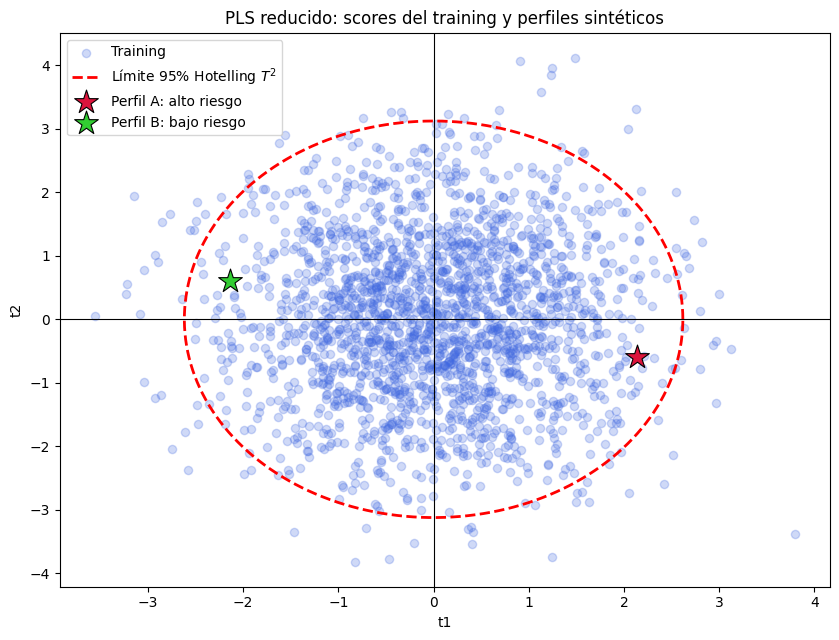

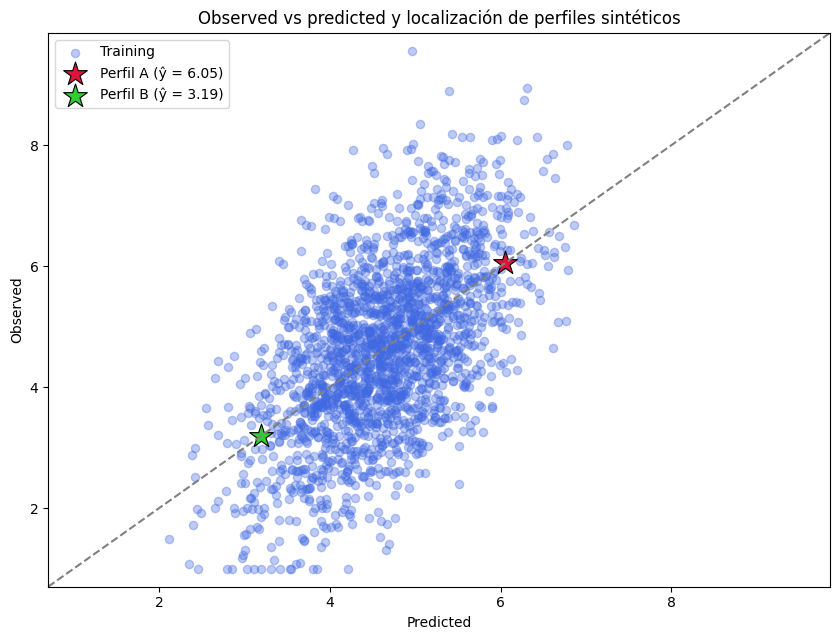

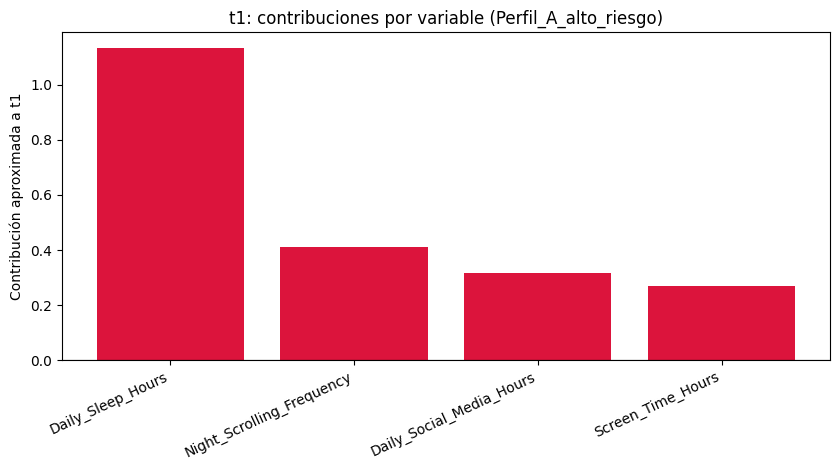

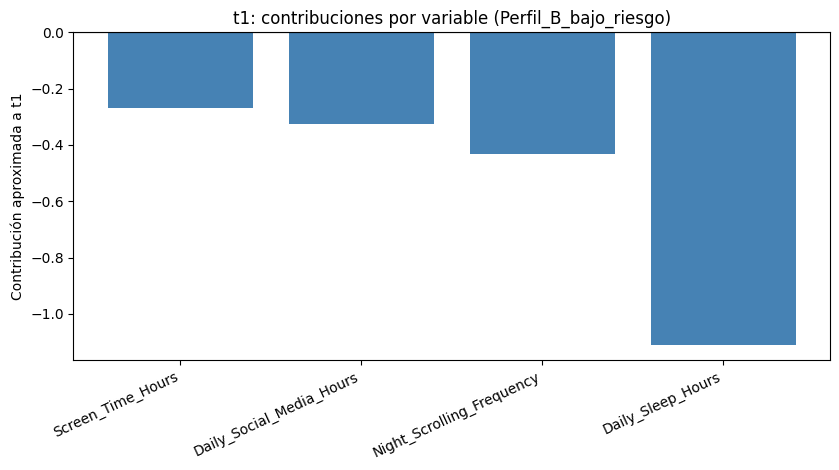

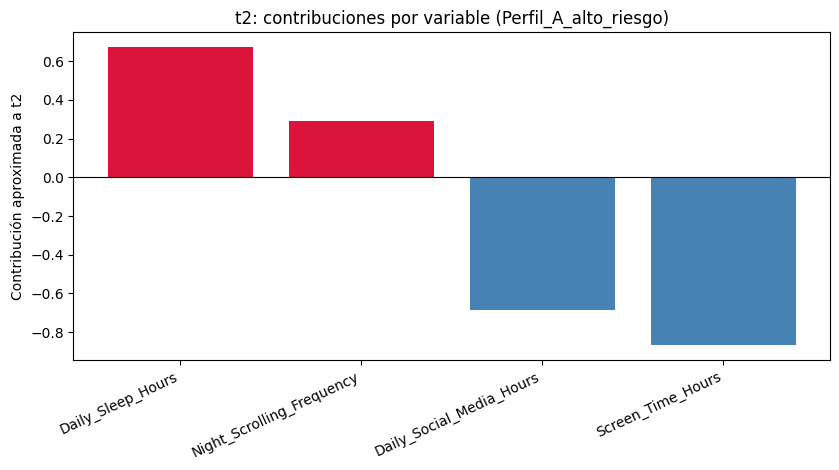

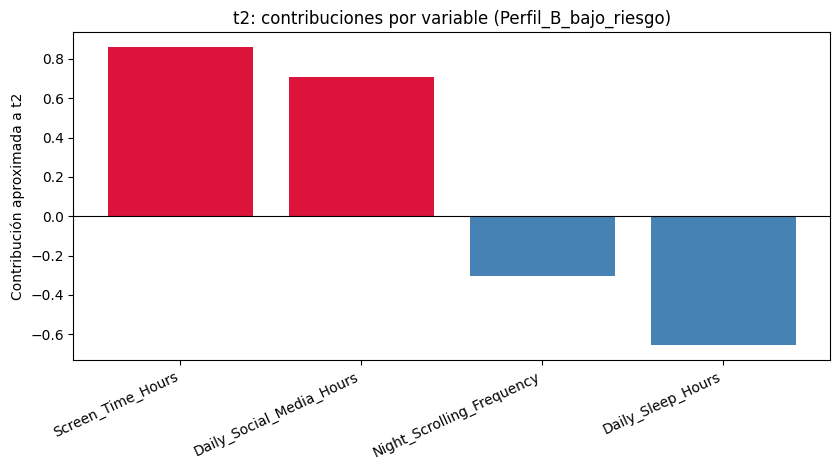

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import f
from sklearn.cross_decomposition import PLSRegression
from sklearn.preprocessing import StandardScaler


# CONFIGURACIÓN
FILE_PATH = Path("/Users/USUARIO/Downloads/Trabajo MOD/GenZ_dataset_con_low.xlsx")
SHEET_NAME = 0

Y_COL = "Anxiety_Score"
X_COLS = [
    "Daily_Social_Media_Hours",
    "Screen_Time_Hours",
    "Night_Scrolling_Frequency",
    "Daily_Sleep_Hours",
]

N_COMPONENTS = 2
PLOT_SCORE_SIGNS = np.array([-1, -1])   # solo para orientar visualmente el score plot y que quede como Dragonet
PERCENTILES = {"P10": 0.10, "P50": 0.50, "P90": 0.90}


# FUNCIONES AUXILIARES
def load_analysis_data(file_path, sheet_name, x_cols, y_col):
    """Carga la hoja de trabajo y conserva únicamente X e Y completas."""
    df = pd.read_excel(file_path, sheet_name=sheet_name)
    data = df[x_cols + [y_col]].dropna().copy()

    X = data[x_cols].copy()
    y = data[[y_col]].copy()

    return data, X, y


def build_synthetic_profiles(X):
    """
    Construye dos perfiles sintéticos a partir de percentiles muestrales:
    - Perfil A: patrón compatible con mayor riesgo esperado
    - Perfil B: patrón compatible con menor riesgo esperado
    """
    quantiles = {name: X.quantile(q) for name, q in PERCENTILES.items()}
    percentiles_df = pd.concat(quantiles, axis=1)

    profile_high_risk = pd.DataFrame(
        [{
            "Daily_Social_Media_Hours": percentiles_df.loc["Daily_Social_Media_Hours", "P90"],
            "Screen_Time_Hours": percentiles_df.loc["Screen_Time_Hours", "P90"],
            "Night_Scrolling_Frequency": percentiles_df.loc["Night_Scrolling_Frequency", "P90"],
            "Daily_Sleep_Hours": percentiles_df.loc["Daily_Sleep_Hours", "P10"],
        }],
        index=["Perfil_A_alto_riesgo"],
    )

    profile_low_risk = pd.DataFrame(
        [{
            "Daily_Social_Media_Hours": percentiles_df.loc["Daily_Social_Media_Hours", "P10"],
            "Screen_Time_Hours": percentiles_df.loc["Screen_Time_Hours", "P10"],
            "Night_Scrolling_Frequency": percentiles_df.loc["Night_Scrolling_Frequency", "P10"],
            "Daily_Sleep_Hours": percentiles_df.loc["Daily_Sleep_Hours", "P90"],
        }],
        index=["Perfil_B_bajo_riesgo"],
    )

    new_profiles = pd.concat([profile_high_risk, profile_low_risk], axis=0)
    return percentiles_df, new_profiles


def fit_pls_model(X, y, n_components):
    """
    Ajusta el modelo PLS sobre X e Y centradas y autoescaladas.
    Devuelve también todos los objetos necesarios para la explotación posterior.
    """
    scaler_x = StandardScaler(with_mean=True, with_std=True)
    scaler_y = StandardScaler(with_mean=True, with_std=True)

    Xz = scaler_x.fit_transform(X)
    yz = scaler_y.fit_transform(y)

    pls = PLSRegression(n_components=n_components, scale=False)
    pls.fit(Xz, yz)

    model = {
        "pls": pls,
        "scaler_x": scaler_x,
        "scaler_y": scaler_y,
        "Xz": Xz,
        "yz": yz,
        "T": pls.x_scores_,
        "P": pls.x_loadings_,
        "Wstar": pls.x_rotations_,
    }
    return model


def compute_training_diagnostics(model, y):
    """Calcula métricas de ajuste y límites de referencia del conjunto training."""
    T = model["T"]
    P = model["P"]
    Xz = model["Xz"]
    pls = model["pls"]
    scaler_y = model["scaler_y"]

    n, a = T.shape

    Xhat_z = T @ P.T
    E_z = Xz - Xhat_z
    spe_train = np.sum(E_z ** 2, axis=1)

    var_t = np.var(T, axis=0, ddof=1)
    t2_train = np.sum((T ** 2) / var_t, axis=1)

    t2_limit_95 = a * (n**2 - 1) / (n * (n - a)) * f.ppf(0.95, a, n - a)
    spe_limit_95 = np.quantile(spe_train, 0.95)

    yhat_train_z = pls.predict(Xz)
    yhat_train = scaler_y.inverse_transform(yhat_train_z).ravel()

    y_obs = y.values.ravel()
    sse = np.sum((y_obs - yhat_train) ** 2)
    sst = np.sum((y_obs - y_obs.mean()) ** 2)
    r2_train = 1 - sse / sst

    diagnostics = {
        "var_t": var_t,
        "SPE_train": spe_train,
        "T2_train": t2_train,
        "T2_limit_95": t2_limit_95,
        "SPE_limit_95": spe_limit_95,
        "yhat_train": yhat_train,
        "R2_train": r2_train,
    }
    return diagnostics


def project_new_profiles(model, diagnostics, new_profiles):
    """
    Proyecta perfiles nuevos sobre el modelo PLS y calcula:
    - scores
    - reconstrucción en X
    - SPE
    - T2
    - predicción de Y
    """
    scaler_x = model["scaler_x"]
    scaler_y = model["scaler_y"]
    Wstar = model["Wstar"]
    P = model["P"]
    pls = model["pls"]

    Xnew_z = scaler_x.transform(new_profiles)

    Tnew = Xnew_z @ Wstar
    Xnew_hat_z = Tnew @ P.T
    Enew_z = Xnew_z - Xnew_hat_z

    spe_new = np.sum(Enew_z ** 2, axis=1)
    t2_new = np.sum((Tnew ** 2) / diagnostics["var_t"], axis=1)

    yhat_new_z = pls.predict(Xnew_z)
    yhat_new = scaler_y.inverse_transform(yhat_new_z).ravel()

    results_new = pd.DataFrame(
        {
            "t1": Tnew[:, 0],
            "t2": Tnew[:, 1],
            "T2": t2_new,
            "SPE": spe_new,
            "T2_extremo_95": t2_new > diagnostics["T2_limit_95"],
            "SPE_atipico_95": spe_new > diagnostics["SPE_limit_95"],
            "Anxiety_predicha": yhat_new,
        },
        index=new_profiles.index,
    )

    projected = {
        "Xnew_z": Xnew_z,
        "Tnew": Tnew,
        "Enew_z": Enew_z,
        "results_new": results_new,
        "yhat_new": yhat_new,
    }
    return projected


def compute_score_contributions(Xnew_z, Wstar, feature_names, profile_names, plot_signs=None):
    """
    Calcula contribuciones aproximadas a cada score:
        contrib_{ij,a} ≈ x*_{ij} · w*_{j,a}

    Se puede aplicar un cambio de signo para alinear la interpretación con el
    score plot mostrado.
    """
    n_components = Wstar.shape[1]
    contributions = {}

    for a in range(n_components):
        contrib = Xnew_z * Wstar[:, a]

        if plot_signs is not None and a < len(plot_signs):
            contrib = contrib * plot_signs[a]

        contributions[f"t{a+1}"] = pd.DataFrame(
            contrib,
            index=profile_names,
            columns=feature_names,
        )

    return contributions


def orient_scores_for_plot(T, signs):
    """Aplica cambios de signo únicamente con fines de lectura gráfica."""
    T_plot = T.copy()
    n_axes = min(T_plot.shape[1], len(signs))

    for j in range(n_axes):
        T_plot[:, j] = T_plot[:, j] * signs[j]

    return T_plot


def plot_score_space(T, Tnew, var_t, t2_limit_95, profile_labels, plot_signs):
    """Representa el espacio de scores del training y los perfiles sintéticos."""
    T_plot = orient_scores_for_plot(T, plot_signs)
    Tnew_plot = orient_scores_for_plot(Tnew, plot_signs)

    theta = np.linspace(0, 2 * np.pi, 400)
    a_ellipse = np.sqrt(t2_limit_95 * var_t[0])
    b_ellipse = np.sqrt(t2_limit_95 * var_t[1])

    ellipse_x = a_ellipse * np.cos(theta)
    ellipse_y = b_ellipse * np.sin(theta)

    plt.figure(figsize=(8.5, 6.5))
    plt.scatter(
        T_plot[:, 0],
        T_plot[:, 1],
        alpha=0.25,
        s=35,
        color="royalblue",
        label="Training",
    )

    plt.plot(
        ellipse_x,
        ellipse_y,
        "--",
        color="red",
        linewidth=2.0,
        label="Límite 95% Hotelling $T^2$",
    )

    colors = ["crimson", "limegreen"]
    for i, label in enumerate(profile_labels):
        plt.scatter(
            Tnew_plot[i, 0],
            Tnew_plot[i, 1],
            marker="*",
            s=320,
            color=colors[i],
            edgecolor="black",
            linewidth=0.8,
            label=label,
        )

    plt.axhline(0, color="black", linewidth=0.8)
    plt.axvline(0, color="black", linewidth=0.8)
    plt.xlabel("t1")
    plt.ylabel("t2")
    plt.title("PLS reducido: scores del training y perfiles sintéticos")
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_observed_vs_predicted(y_obs, yhat_train, yhat_new, profile_names):
    """
    Observed vs predicted del training.
    Los perfiles sintéticos se sitúan sobre la diagonal únicamente como referencia
    visual de su valor predicho, ya que no existe valor observado real.
    """
    plt.figure(figsize=(8.5, 6.5))
    plt.scatter(
        yhat_train,
        y_obs,
        alpha=0.35,
        s=35,
        color="royalblue",
        label="Training",
    )

    colors = ["crimson", "limegreen"]
    for i, profile_name in enumerate(profile_names):
        plt.scatter(
            yhat_new[i],
            yhat_new[i],
            marker="*",
            s=320,
            color=colors[i],
            edgecolor="black",
            linewidth=0.8,
            label=f"{profile_name} (ŷ = {yhat_new[i]:.2f})",
        )

    lim_min = min(np.min(yhat_train), np.min(y_obs), np.min(yhat_new)) - 0.3
    lim_max = max(np.max(yhat_train), np.max(y_obs), np.max(yhat_new)) + 0.3

    plt.plot([lim_min, lim_max], [lim_min, lim_max], "--", color="gray", linewidth=1.5)
    plt.xlim(lim_min, lim_max)
    plt.ylim(lim_min, lim_max)
    plt.xlabel("Predicted")
    plt.ylabel("Observed")
    plt.title("Observed vs predicted y localización de perfiles sintéticos")
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_score_contributions(contributions):
    """Genera un gráfico de barras por perfil y por componente."""
    for score_name, contrib_df in contributions.items():
        for profile_name in contrib_df.index:
            values = contrib_df.loc[profile_name].sort_values(ascending=False)
            colors = ["crimson" if value > 0 else "steelblue" for value in values.values]

            plt.figure(figsize=(8.5, 4.8))
            plt.bar(values.index, values.values, color=colors)
            plt.axhline(0, color="black", linewidth=0.8)
            plt.xticks(rotation=25, ha="right")
            plt.ylabel(f"Contribución aproximada a {score_name}")
            plt.title(f"{score_name}: contribuciones por variable ({profile_name})")
            plt.tight_layout()
            plt.show()


# SCRIPT PRINCIPAL
def main():
    _, X, y = load_analysis_data(FILE_PATH, SHEET_NAME, X_COLS, Y_COL)

    n = len(X)
    print(f"N = {n}")
    print(f"Variables X = {X_COLS}")

    percentiles_df, new_profiles = build_synthetic_profiles(X)

    print("\n--- Percentiles usados para construir los perfiles ---")
    print(percentiles_df)

    print("\n--- Nuevos individuos sintéticos ---")
    print(new_profiles)

    model = fit_pls_model(X, y, N_COMPONENTS)
    diagnostics = compute_training_diagnostics(model, y)

    print("\n--- Resumen training ---")
    print(f"R2 training = {diagnostics['R2_train']:.4f}")
    print(f"T2 límite 95% = {diagnostics['T2_limit_95']:.4f}")
    print(f"SPE límite 95% = {diagnostics['SPE_limit_95']:.4f}")

    projected = project_new_profiles(model, diagnostics, new_profiles)

    print("\n--- Resultados de los nuevos individuos ---")
    print(projected["results_new"])

    contributions = compute_score_contributions(
        Xnew_z=projected["Xnew_z"],
        Wstar=model["Wstar"],
        feature_names=X_COLS,
        profile_names=new_profiles.index,
        plot_signs=PLOT_SCORE_SIGNS,
    )

    print("\n--- Contribuciones aproximadas a t1 ---")
    print(contributions["t1"].T)

    print("\n--- Contribuciones aproximadas a t2 ---")
    print(contributions["t2"].T)

    plot_score_space(
        T=model["T"],
        Tnew=projected["Tnew"],
        var_t=diagnostics["var_t"],
        t2_limit_95=diagnostics["T2_limit_95"],
        profile_labels=["Perfil A: alto riesgo", "Perfil B: bajo riesgo"],
        plot_signs=PLOT_SCORE_SIGNS,
    )

    plot_observed_vs_predicted(
        y_obs=y.values.ravel(),
        yhat_train=diagnostics["yhat_train"],
        yhat_new=projected["yhat_new"],
        profile_names=["Perfil A", "Perfil B"],
    )

    plot_score_contributions(contributions)


if __name__ == "__main__":
    main()

El siguiente código corresponde al análisis desarrollado para el modelo de regresión en componentes principales (PCR) del apartado 3.2.3, incluyendo su ajuste, validación cruzada, obtención de coeficientes e interpretación gráfica.

PCR - OBJETIVO 1
N = 2064
Variables X = 8
Respuesta Y = Anxiety_Score

--- Validación PCR ---
 A      RY2      QY2
 1 0.028636 0.024816
 2 0.033104 0.101409
 3 0.233558 0.215095
 4 0.236154 0.222105
 5 0.252121 0.239713
 6 0.276052 0.267952
 7 0.314787 0.307588
 8 0.316018 0.308288

A óptimo seleccionado por validación cruzada = 8
RY2 = 0.3160
QY2 = 0.3083

--- Varianza explicada en X por las componentes retenidas ---
PC1: 0.2308
PC2: 0.1295
PC3: 0.1290
PC4: 0.1253
PC5: 0.1237
PC6: 0.1226
PC7: 0.1179
PC8: 0.0212
Acumulada: 1.0000

--- Coeficientes PCR ---
                   Variable  Beta_original  Beta_estandarizado
          Daily_Sleep_Hours      -0.556848           -0.507017
  Night_Scrolling_Frequency       0.205772            0.180912
   Daily_Social_Media_Hours       0.112817            0.122168
   Study_Work_Hours_per_Day       0.012523            0.017838
       Caffeine_Intake_Cups       0.020641            0.014120
Exercise_Frequency_per_Week      -0.010922           -0.0117

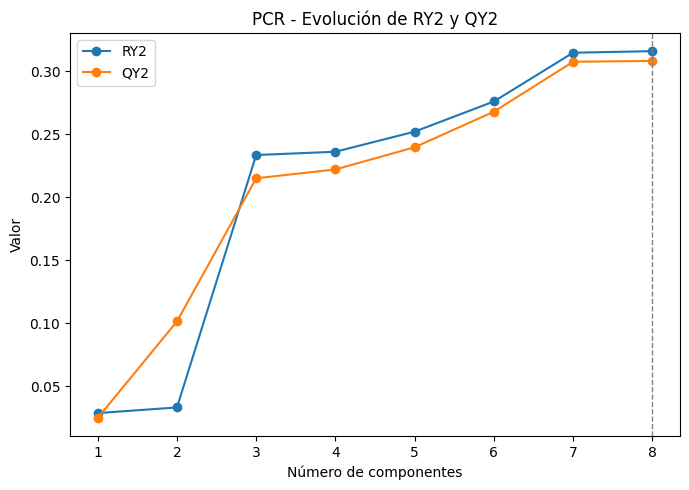

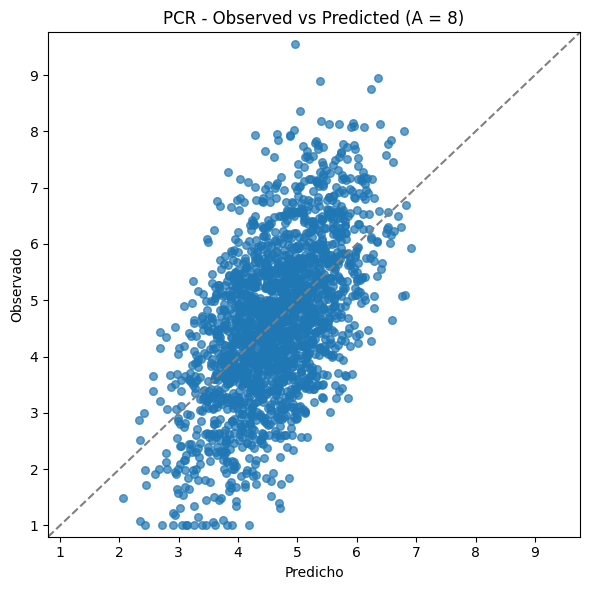

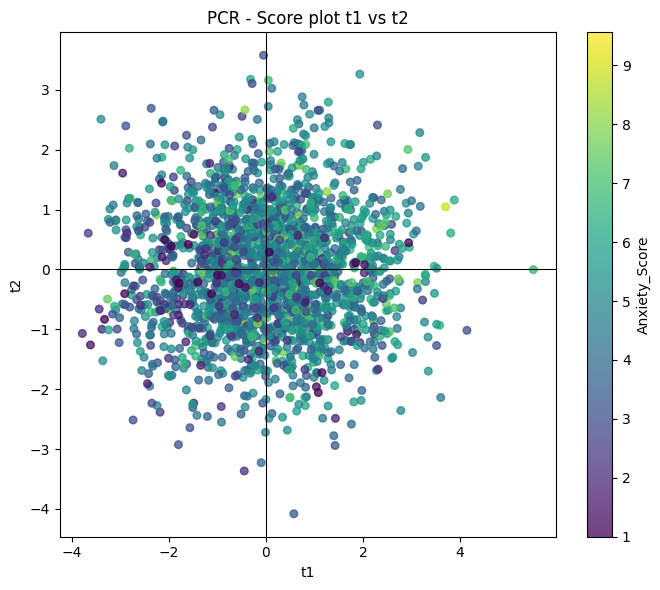

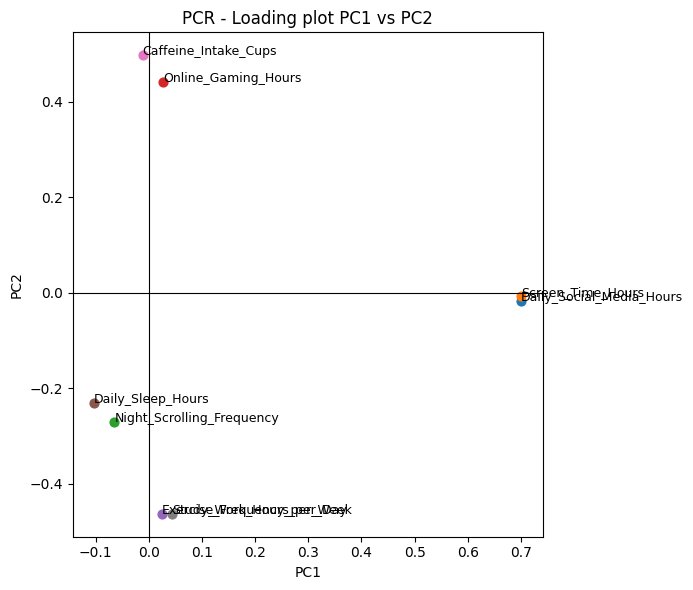

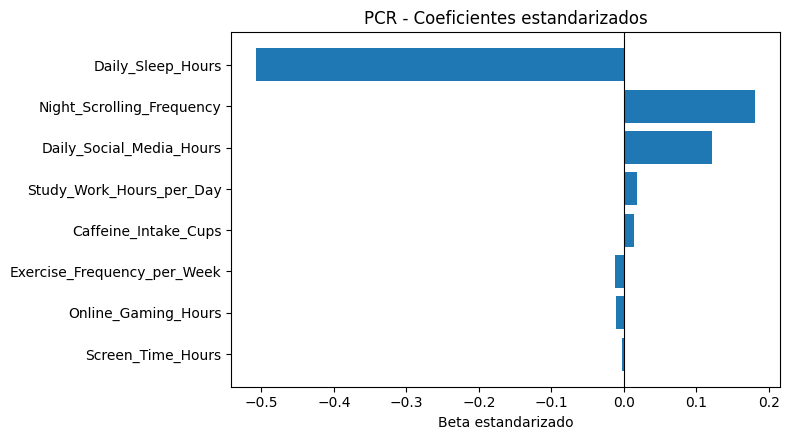

In [3]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score


# CONFIGURACIÓN
FILE_PATH = Path(r"C:\Users\USUARIO\Downloads\Trabajo MOD\GenZ_dataset_con_low.xlsx")
SHEET_NAME = 0

Y_COL = "Anxiety_Score"
X_COLS = [
    "Daily_Social_Media_Hours",
    "Screen_Time_Hours",
    "Night_Scrolling_Frequency",
    "Online_Gaming_Hours",
    "Exercise_Frequency_per_Week",
    "Daily_Sleep_Hours",
    "Caffeine_Intake_Cups",
    "Study_Work_Hours_per_Day",
]

N_SPLITS = 7
RANDOM_STATE = 42
MAX_COMPONENTS = len(X_COLS)


# FUNCIONES AUXILIARES
def load_data(file_path: Path, sheet_name, x_cols, y_col):
    """Carga los datos y conserva únicamente observaciones completas."""
    if not file_path.exists():
        raise FileNotFoundError(f"No se encontró el archivo: {file_path}")

    df = pd.read_excel(file_path, sheet_name=sheet_name)
    data = df[x_cols + [y_col]].dropna().copy()

    X = data[x_cols].copy()
    y = data[y_col].copy()

    return data, X, y


def fit_pcr(X: pd.DataFrame, y: pd.Series, n_components: int):
    """
    Ajusta un modelo PCR sobre todos los datos:
    1) autoescalado de X
    2) PCA sobre X
    3) regresión lineal de scores sobre y

    Devuelve los objetos necesarios para interpretar el modelo.
    """
    scaler_x = StandardScaler(with_mean=True, with_std=True)
    Xz = scaler_x.fit_transform(X)

    pca = PCA(n_components=n_components, svd_solver="full")
    T = pca.fit_transform(Xz)

    reg = LinearRegression()
    reg.fit(T, y)

    yhat = reg.predict(T)
    ry2 = r2_score(y, yhat)

    # Coeficientes del modelo en el espacio X escalado
    beta_scaled_x = pca.components_[:n_components, :].T @ reg.coef_.ravel()

    # Coeficientes en unidades originales
    beta_original = beta_scaled_x / scaler_x.scale_
    intercept_original = reg.intercept_ - np.sum(beta_original * scaler_x.mean_)

    # Coeficientes estandarizados (X estandarizada e y estandarizada)
    scaler_y = StandardScaler(with_mean=True, with_std=True)
    yz = scaler_y.fit_transform(np.asarray(y).reshape(-1, 1)).ravel()

    reg_std = LinearRegression()
    reg_std.fit(T, yz)
    beta_standardized = pca.components_[:n_components, :].T @ reg_std.coef_.ravel()

    return {
        "scaler_x": scaler_x,
        "pca": pca,
        "reg": reg,
        "T": T,
        "yhat": yhat,
        "RY2": ry2,
        "beta_original": beta_original,
        "intercept_original": intercept_original,
        "beta_standardized": beta_standardized,
        "explained_variance_ratio": pca.explained_variance_ratio_,
        "loadings": pca.components_.T,
    }


def q2_cv_pcr(
    X: pd.DataFrame,
    y: pd.Series,
    n_components: int,
    n_splits: int = 7,
    random_state: int = 42,
):
    """
    Calcula Q2 mediante validación cruzada, reestimando en cada fold:
    - el escalado
    - el PCA
    - la regresión sobre scores

    Así se evita fuga de información.
    """
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    y_array = np.asarray(y).ravel()
    y_pred_cv = np.zeros_like(y_array, dtype=float)

    for train_idx, test_idx in kf.split(X):
        X_train = X.iloc[train_idx]
        X_test = X.iloc[test_idx]
        y_train = y_array[train_idx]

        scaler_x = StandardScaler(with_mean=True, with_std=True)
        X_train_z = scaler_x.fit_transform(X_train)
        X_test_z = scaler_x.transform(X_test)

        pca = PCA(n_components=n_components, svd_solver="full")
        T_train = pca.fit_transform(X_train_z)
        T_test = pca.transform(X_test_z)

        reg = LinearRegression()
        reg.fit(T_train, y_train)

        y_pred_cv[test_idx] = reg.predict(T_test)

    press = np.sum((y_array - y_pred_cv) ** 2)
    sst = np.sum((y_array - np.mean(y_array)) ** 2)
    qy2 = 1 - press / sst

    return qy2, y_pred_cv


def evaluate_component_grid(
    X: pd.DataFrame,
    y: pd.Series,
    max_components: int,
    n_splits: int,
    random_state: int,
):
    """Evalúa PCR para A = 1, ..., max_components."""
    results = []

    for a in range(1, max_components + 1):
        qy2, _ = q2_cv_pcr(
            X=X,
            y=y,
            n_components=a,
            n_splits=n_splits,
            random_state=random_state,
        )

        full_model = fit_pcr(X, y, n_components=a)

        results.append(
            {
                "A": a,
                "RY2": full_model["RY2"],
                "QY2": qy2,
            }
        )

    results_df = pd.DataFrame(results)
    return results_df


def make_loading_plot(loadings, var_names, comp_x=1, comp_y=2):
    """Loading plot de dos componentes."""
    ix = comp_x - 1
    iy = comp_y - 1

    plt.figure(figsize=(7, 6))
    plt.axhline(0, color="black", linewidth=0.8)
    plt.axvline(0, color="black", linewidth=0.8)

    for i, name in enumerate(var_names):
        x_coord = loadings[i, ix]
        y_coord = loadings[i, iy]
        plt.scatter(x_coord, y_coord, s=40)
        plt.text(x_coord, y_coord, name, fontsize=9)

    plt.xlabel(f"PC{comp_x}")
    plt.ylabel(f"PC{comp_y}")
    plt.title(f"PCR - Loading plot PC{comp_x} vs PC{comp_y}")
    plt.tight_layout()
    plt.show()


def make_score_plot(T, y, comp_x=1, comp_y=2):
    """Score plot coloreado según la variable respuesta."""
    ix = comp_x - 1
    iy = comp_y - 1

    plt.figure(figsize=(7, 6))
    scatter = plt.scatter(T[:, ix], T[:, iy], c=y, s=30, alpha=0.75)
    plt.colorbar(scatter, label=Y_COL)
    plt.axhline(0, color="black", linewidth=0.8)
    plt.axvline(0, color="black", linewidth=0.8)
    plt.xlabel(f"t{comp_x}")
    plt.ylabel(f"t{comp_y}")
    plt.title(f"PCR - Score plot t{comp_x} vs t{comp_y}")
    plt.tight_layout()
    plt.show()


def plot_validation_curve(results_df: pd.DataFrame, a_opt: int):
    """Representa la evolución de RY2 y QY2 con el número de componentes."""
    plt.figure(figsize=(7, 5))
    plt.plot(results_df["A"], results_df["RY2"], marker="o", label="RY2")
    plt.plot(results_df["A"], results_df["QY2"], marker="o", label="QY2")
    plt.axvline(a_opt, color="gray", linestyle="--", linewidth=1)
    plt.xlabel("Número de componentes")
    plt.ylabel("Valor")
    plt.title("PCR - Evolución de RY2 y QY2")
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_observed_vs_predicted(y_obs, yhat, a_opt: int):
    """Observed vs predicted del modelo final."""
    plt.figure(figsize=(6, 6))
    plt.scatter(yhat, y_obs, alpha=0.7, s=30)

    lim_min = min(np.min(yhat), np.min(y_obs)) - 0.2
    lim_max = max(np.max(yhat), np.max(y_obs)) + 0.2

    plt.plot([lim_min, lim_max], [lim_min, lim_max], "--", color="gray")
    plt.xlim(lim_min, lim_max)
    plt.ylim(lim_min, lim_max)
    plt.xlabel("Predicho")
    plt.ylabel("Observado")
    plt.title(f"PCR - Observed vs Predicted (A = {a_opt})")
    plt.tight_layout()
    plt.show()


def plot_standardized_coefficients(coef_df: pd.DataFrame):
    """Representa los coeficientes estandarizados del modelo final."""
    plt.figure(figsize=(8, 4.5))
    coef_plot = coef_df.iloc[::-1]
    plt.barh(coef_plot["Variable"], coef_plot["Beta_estandarizado"])
    plt.axvline(0, color="black", linewidth=0.8)
    plt.xlabel("Beta estandarizado")
    plt.title("PCR - Coeficientes estandarizados")
    plt.tight_layout()
    plt.show()


def print_console_summary(
    data: pd.DataFrame,
    x_cols,
    y_col: str,
    results_df: pd.DataFrame,
    a_opt: int,
    model: dict,
    coef_df: pd.DataFrame,
):
    """Imprime un resumen completo del análisis para usar directamente en el trabajo."""
    expl_var = model["explained_variance_ratio"]

    print("=" * 90)
    print("PCR - OBJETIVO 1")
    print("=" * 90)
    print(f"N = {len(data)}")
    print(f"Variables X = {len(x_cols)}")
    print(f"Respuesta Y = {y_col}")
    print()

    print("--- Validación PCR ---")
    print(results_df.to_string(index=False))
    print()

    best_row = results_df.loc[results_df["A"] == a_opt].iloc[0]
    print(f"A óptimo seleccionado por validación cruzada = {a_opt}")
    print(f"RY2 = {best_row['RY2']:.4f}")
    print(f"QY2 = {best_row['QY2']:.4f}")
    print()

    print("--- Varianza explicada en X por las componentes retenidas ---")
    for i, value in enumerate(expl_var[:a_opt], start=1):
        print(f"PC{i}: {value:.4f}")
    print(f"Acumulada: {np.sum(expl_var[:a_opt]):.4f}")
    print()

    print("--- Coeficientes PCR ---")
    print(coef_df.to_string(index=False))
    print()

    print("--- Ecuación del modelo en unidades originales ---")
    intercept = model["intercept_original"]
    print(f"Intercepto = {intercept:.6f}")
    for var_name, beta in zip(x_cols, model["beta_original"]):
        print(f"{var_name}: {beta:.6f}")
    print()


# SCRIPT PRINCIPAL
def main():
    data, X, y = load_data(FILE_PATH, SHEET_NAME, X_COLS, Y_COL)

    results_df = evaluate_component_grid(
        X=X,
        y=y,
        max_components=MAX_COMPONENTS,
        n_splits=N_SPLITS,
        random_state=RANDOM_STATE,
    )

    # Se selecciona el menor número de componentes que maximiza QY2
    a_opt = int(results_df.loc[results_df["QY2"].idxmax(), "A"])

    model = fit_pcr(X, y, n_components=a_opt)

    coef_df = pd.DataFrame(
        {
            "Variable": X_COLS,
            "Beta_original": model["beta_original"],
            "Beta_estandarizado": model["beta_standardized"],
        }
    ).sort_values(
        by="Beta_estandarizado",
        key=lambda series: np.abs(series),
        ascending=False,
    )

    print_console_summary(
        data=data,
        x_cols=X_COLS,
        y_col=Y_COL,
        results_df=results_df,
        a_opt=a_opt,
        model=model,
        coef_df=coef_df,
    )

    plot_validation_curve(results_df, a_opt)
    plot_observed_vs_predicted(y_obs=y.values, yhat=model["yhat"], a_opt=a_opt)

    if a_opt >= 2:
        make_score_plot(T=model["T"], y=y.values, comp_x=1, comp_y=2)
        make_loading_plot(
            loadings=model["loadings"],
            var_names=X_COLS,
            comp_x=1,
            comp_y=2,
        )

    plot_standardized_coefficients(coef_df)


if __name__ == "__main__":
    main()

K-MEANS - OBJETIVO 1
N = 2064
Variables X = 8
Valores de K evaluados = [2, 3, 4, 5, 6]

--- Comparación de K ---
 K  Inercia_media  Inercia_sd  Silhouette_media  Silhouette_sd  Calinski_Harabasz_media  Calinski_Harabasz_sd  ARI_media  ARI_min  Rank_medio
 2   14076.472068    0.002145          0.133784       0.000005               356.769997              0.000534   0.995497 0.990329        1.00
 3   13134.276157    0.956474          0.102742       0.000591               265.016088              0.094258   0.836460 0.550458        2.50
 4   12353.115054    1.184784          0.099353       0.000544               231.180454              0.088549   0.749029 0.522363        3.50
 5   11721.005417    3.244236          0.094826       0.000384               210.405795              0.200545   0.887748 0.719959        3.25
 6   11210.986419    5.792282          0.095093       0.001118               194.622361              0.313209   0.632142 0.393012        4.75

K sugerido solo por silhouette = 2

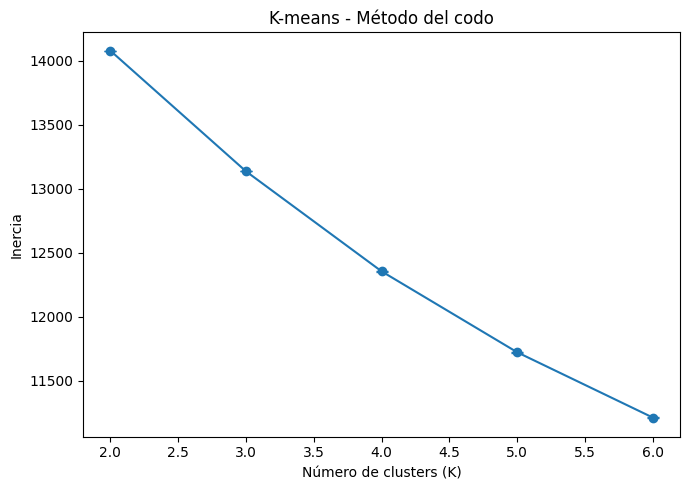

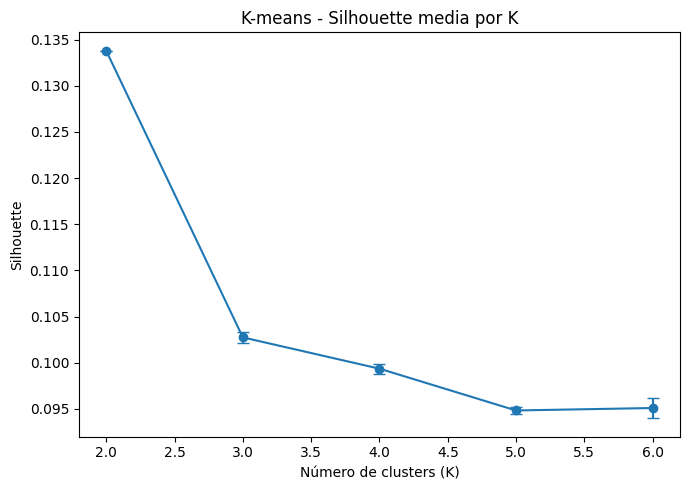

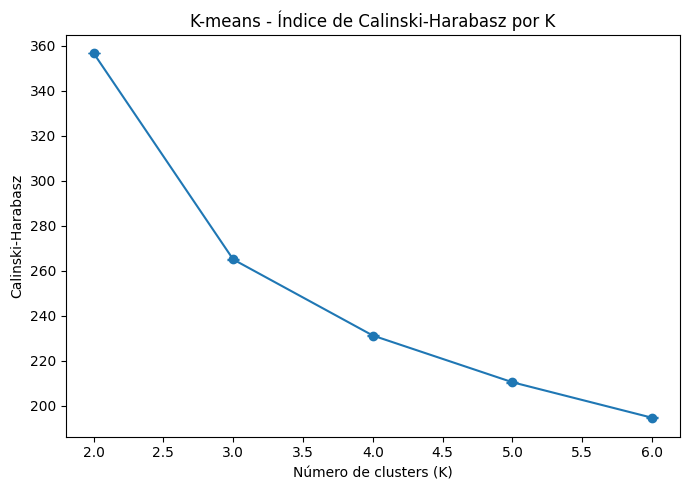

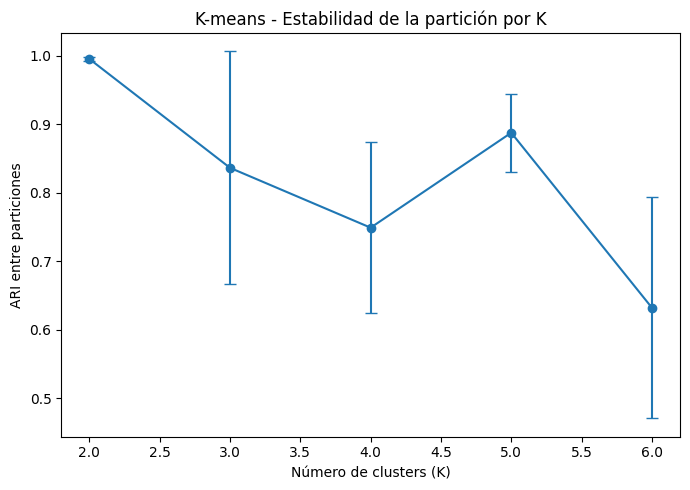

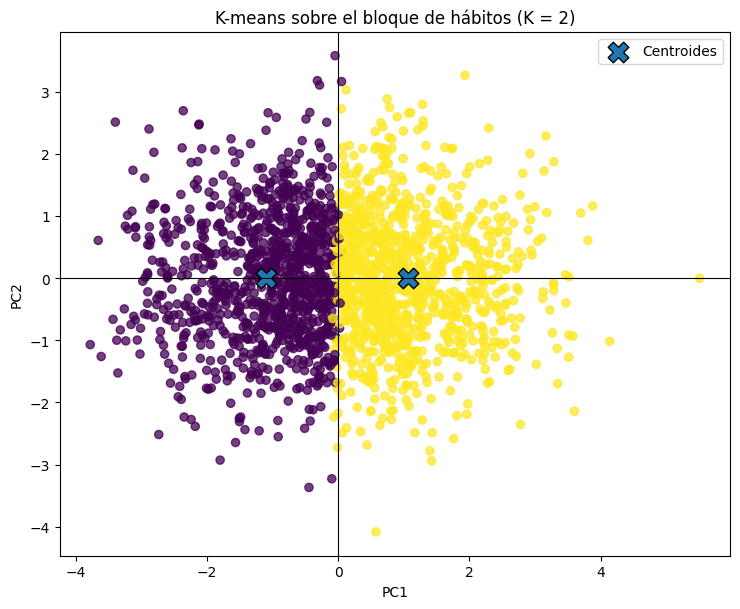

<Figure size 700x500 with 0 Axes>

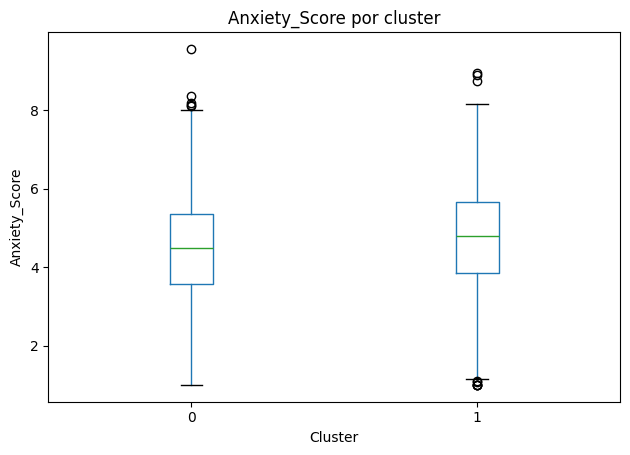

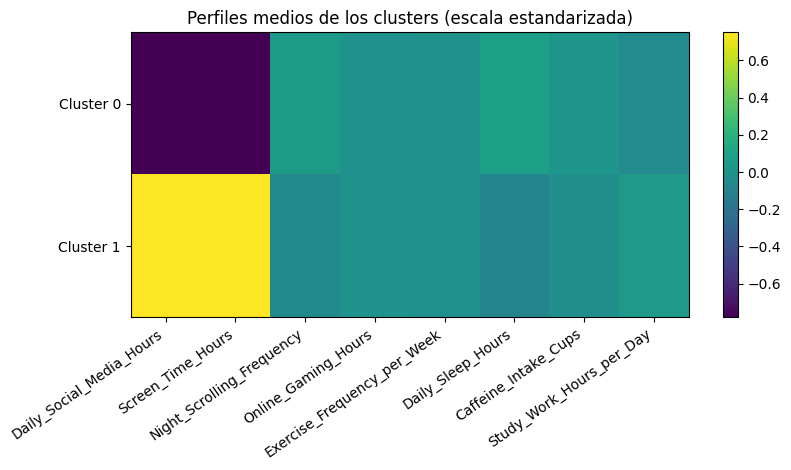

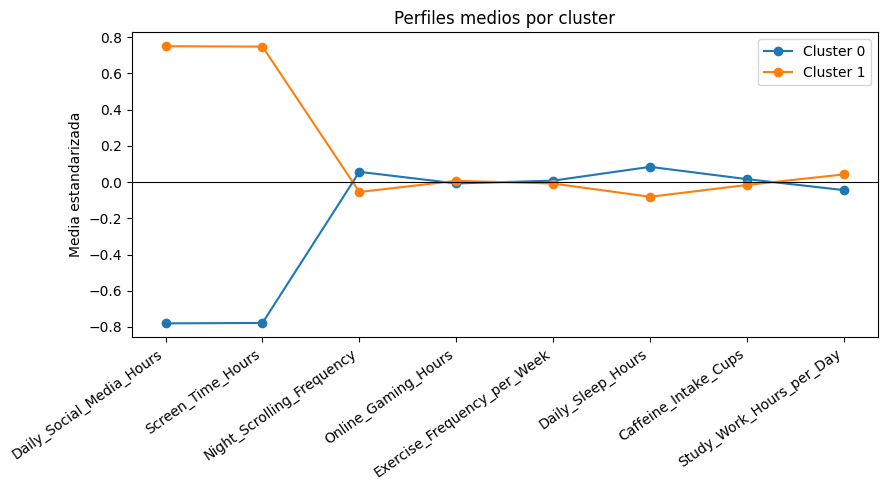

In [4]:
from pathlib import Path
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    adjusted_rand_score,
)
from sklearn.decomposition import PCA


# CONFIGURACIÓN
FILE_PATH = Path(r"C:\Users\USUARIO\Downloads\Trabajo MOD\GenZ_dataset_con_low.xlsx")
SHEET_NAME = 0

Y_COL = "Anxiety_Score"
X_COLS = [
    "Daily_Social_Media_Hours",
    "Screen_Time_Hours",
    "Night_Scrolling_Frequency",
    "Online_Gaming_Hours",
    "Exercise_Frequency_per_Week",
    "Daily_Sleep_Hours",
    "Caffeine_Intake_Cups",
    "Study_Work_Hours_per_Day",
]

K_VALUES = [2, 3, 4, 5, 6]
RANDOM_STATE = 42
N_INIT = 50
N_REPEATS = 20   # repeticiones independientes por cada K para evaluar robustez


# FUNCIONES AUXILIARES
def load_data(file_path: Path, sheet_name, x_cols, y_col):
    """Carga los datos y conserva únicamente observaciones completas."""
    if not file_path.exists():
        raise FileNotFoundError(f"No se encontró el archivo: {file_path}")

    df = pd.read_excel(file_path, sheet_name=sheet_name)

    missing_cols = [col for col in x_cols + [y_col] if col not in df.columns]
    if missing_cols:
        raise ValueError(f"Faltan columnas en el Excel: {missing_cols}")

    data = df[x_cols + [y_col]].dropna().copy()
    if data.empty:
        raise ValueError("Tras eliminar NA no quedan observaciones válidas.")

    X = data[x_cols].copy()
    y = data[y_col].copy()

    return data, X, y


def sanitize_k_values(k_values, n_samples):
    """
    Filtra valores de K no válidos:
    - K >= 2
    - K < n_samples
    - sin duplicados
    """
    valid_k = sorted({int(k) for k in k_values if 2 <= int(k) < n_samples})

    if not valid_k:
        raise ValueError(
            "No hay valores válidos de K. Deben cumplir 2 <= K < número de observaciones."
        )

    return valid_k


def standardize_features(X: pd.DataFrame):
    """Centra y autoescala la matriz X."""
    scaler_x = StandardScaler(with_mean=True, with_std=True)
    Xz = scaler_x.fit_transform(X)
    return scaler_x, Xz


def compute_partition_stability(label_list):
    """
    Calcula la estabilidad entre particiones a partir del ARI
    para todas las parejas de soluciones obtenidas con el mismo K.
    """
    if len(label_list) < 2:
        return {
            "ARI_media": np.nan,
            "ARI_sd": np.nan,
            "ARI_min": np.nan,
            "ARI_max": np.nan,
        }

    ari_values = [
        adjusted_rand_score(labels_a, labels_b)
        for labels_a, labels_b in combinations(label_list, 2)
    ]

    return {
        "ARI_media": float(np.mean(ari_values)),
        "ARI_sd": float(np.std(ari_values, ddof=1)) if len(ari_values) > 1 else 0.0,
        "ARI_min": float(np.min(ari_values)),
        "ARI_max": float(np.max(ari_values)),
    }


def fit_kmeans_repeatedly(Xz, k, n_repeats=20, n_init=50, random_state=42):
    """
    Ajusta K-means múltiples veces para un K dado y resume:
    - inercia
    - silhouette
    - Calinski-Harabasz
    - estabilidad ARI entre particiones
    Además conserva el mejor modelo según silhouette.
    """
    all_labels = []
    all_inertia = []
    all_silhouette = []
    all_ch = []
    fitted_models = []

    for rep in range(n_repeats):
        seed = random_state + rep

        km = KMeans(
            n_clusters=k,
            random_state=seed,
            n_init=n_init,
        )
        labels = km.fit_predict(Xz)

        inertia = km.inertia_
        sil = silhouette_score(Xz, labels)
        ch = calinski_harabasz_score(Xz, labels)

        all_labels.append(labels)
        all_inertia.append(inertia)
        all_silhouette.append(sil)
        all_ch.append(ch)
        fitted_models.append(km)

    stability = compute_partition_stability(all_labels)

    best_idx = int(np.argmax(all_silhouette))
    best_model = fitted_models[best_idx]
    best_labels = all_labels[best_idx]

    summary = {
        "K": k,
        "Inercia_media": float(np.mean(all_inertia)),
        "Inercia_sd": float(np.std(all_inertia, ddof=1)) if len(all_inertia) > 1 else 0.0,
        "Silhouette_media": float(np.mean(all_silhouette)),
        "Silhouette_sd": float(np.std(all_silhouette, ddof=1)) if len(all_silhouette) > 1 else 0.0,
        "Calinski_Harabasz_media": float(np.mean(all_ch)),
        "Calinski_Harabasz_sd": float(np.std(all_ch, ddof=1)) if len(all_ch) > 1 else 0.0,
        "ARI_media": stability["ARI_media"],
        "ARI_sd": stability["ARI_sd"],
        "ARI_min": stability["ARI_min"],
        "ARI_max": stability["ARI_max"],
        "best_model": best_model,
        "best_labels": best_labels,
        "best_silhouette": float(all_silhouette[best_idx]),
    }

    return summary


def evaluate_k_grid(Xz, k_values, n_repeats=20, n_init=50, random_state=42):
    """Evalúa la rejilla de valores K y devuelve un resumen por cada K."""
    evaluation_rows = []

    for k in k_values:
        row = fit_kmeans_repeatedly(
            Xz=Xz,
            k=k,
            n_repeats=n_repeats,
            n_init=n_init,
            random_state=random_state,
        )
        evaluation_rows.append(row)

    return evaluation_rows


def build_selection_table(evaluation_rows):
    """
    Construye la tabla de selección de K.
    El criterio final se apoya en:
    - silhouette media
    - Calinski-Harabasz medio
    - estabilidad ARI media
    - estabilidad ARI mínima
    """
    rows_for_df = []
    for row in evaluation_rows:
        rows_for_df.append(
            {
                "K": row["K"],
                "Inercia_media": row["Inercia_media"],
                "Inercia_sd": row["Inercia_sd"],
                "Silhouette_media": row["Silhouette_media"],
                "Silhouette_sd": row["Silhouette_sd"],
                "Calinski_Harabasz_media": row["Calinski_Harabasz_media"],
                "Calinski_Harabasz_sd": row["Calinski_Harabasz_sd"],
                "ARI_media": row["ARI_media"],
                "ARI_sd": row["ARI_sd"],
                "ARI_min": row["ARI_min"],
                "ARI_max": row["ARI_max"],
            }
        )

    res_df = pd.DataFrame(rows_for_df)

    # Ranking conjunto: cuanto menor, mejor
    res_df["Rank_silhouette"] = res_df["Silhouette_media"].rank(
        ascending=False, method="min"
    )
    res_df["Rank_CH"] = res_df["Calinski_Harabasz_media"].rank(
        ascending=False, method="min"
    )
    res_df["Rank_ARI_media"] = res_df["ARI_media"].rank(
        ascending=False, method="min"
    )
    res_df["Rank_ARI_min"] = res_df["ARI_min"].rank(
        ascending=False, method="min"
    )

    res_df["Rank_medio"] = res_df[
        ["Rank_silhouette", "Rank_CH", "Rank_ARI_media", "Rank_ARI_min"]
    ].mean(axis=1)

    return res_df


def choose_best_k(res_df: pd.DataFrame):
    """
    Selecciona el K final usando el ranking conjunto.
    En caso de empate, prioriza mayor silhouette y mayor estabilidad media.
    """
    best_row = (
        res_df.sort_values(
            by=["Rank_medio", "Silhouette_media", "ARI_media", "Calinski_Harabasz_media"],
            ascending=[True, False, False, False],
        )
        .iloc[0]
    )
    return int(best_row["K"])


def get_best_run_for_k(evaluation_rows, best_k):
    """Recupera el mejor ajuste individual correspondiente al K seleccionado."""
    for row in evaluation_rows:
        if row["K"] == best_k:
            return row["best_model"], row["best_labels"]
    raise ValueError(f"No se encontró información para K = {best_k}")


def relabel_clusters_by_anxiety(labels, y):
    """
    Reetiqueta los clusters ordenándolos según la media creciente de Anxiety_Score.
    Esto no cambia la partición, solo mejora la interpretación.
    """
    tmp = pd.DataFrame({"Cluster": labels, "Anxiety": y})
    order = tmp.groupby("Cluster")["Anxiety"].mean().sort_values().index.tolist()
    mapping = {old_label: new_label for new_label, old_label in enumerate(order)}
    new_labels = np.array([mapping[label] for label in labels], dtype=int)
    return new_labels, mapping


def reorder_centroids(centers, mapping):
    """Reordena los centroides conforme a la nueva codificación de clusters."""
    reordered = np.zeros_like(centers)
    for old_label, new_label in mapping.items():
        reordered[new_label, :] = centers[old_label, :]
    return reordered


def summarize_clusters(data, Xz, labels, x_cols, y_col):
    """Genera los resúmenes principales de la solución final."""
    data_clustered = data.copy()
    data_clustered["Cluster"] = labels

    cluster_sizes = data_clustered["Cluster"].value_counts().sort_index()

    cluster_means_original = data_clustered.groupby("Cluster")[x_cols + [y_col]].mean()

    cluster_profiles_z = pd.DataFrame(Xz, columns=x_cols)
    cluster_profiles_z["Cluster"] = labels
    cluster_profiles_z = cluster_profiles_z.groupby("Cluster")[x_cols].mean()

    anxiety_summary = data_clustered.groupby("Cluster")[y_col].agg(
        n="count",
        media="mean",
        sd="std",
        mediana="median",
        minimo="min",
        maximo="max",
    )

    return data_clustered, cluster_sizes, cluster_means_original, cluster_profiles_z, anxiety_summary


def print_console_summary(
    data,
    x_cols,
    y_col,
    k_values,
    res_df,
    best_k,
    cluster_sizes,
    cluster_means_original,
    cluster_profiles_z,
    anxiety_summary,
):
    """Imprime un resumen completo de resultados."""
    print("=" * 95)
    print("K-MEANS - OBJETIVO 1")
    print("=" * 95)
    print(f"N = {len(data)}")
    print(f"Variables X = {len(x_cols)}")
    print(f"Valores de K evaluados = {k_values}")
    print()

    print("--- Comparación de K ---")
    print(
        res_df[
            [
                "K",
                "Inercia_media",
                "Inercia_sd",
                "Silhouette_media",
                "Silhouette_sd",
                "Calinski_Harabasz_media",
                "Calinski_Harabasz_sd",
                "ARI_media",
                "ARI_min",
                "Rank_medio",
            ]
        ].to_string(index=False)
    )
    print()

    k_silhouette = int(res_df.loc[res_df["Silhouette_media"].idxmax(), "K"])
    print(f"K sugerido solo por silhouette = {k_silhouette}")
    print(f"K seleccionado por criterio conjunto = {best_k}")
    print()

    print("--- Tamaños de cluster ---")
    print(cluster_sizes.to_string())
    print()

    print("--- Medias por cluster (escala original) ---")
    print(cluster_means_original.to_string())
    print()

    print("--- Perfiles medios de cluster (escala estandarizada) ---")
    print(cluster_profiles_z.to_string())
    print()

    print(f"--- Resumen de {y_col} por cluster ---")
    print(anxiety_summary.to_string())
    print()


# FUNCIONES DE REPRESENTACIÓN
def plot_inertia_curve(res_df):
    plt.figure(figsize=(7, 5))
    plt.errorbar(
        res_df["K"],
        res_df["Inercia_media"],
        yerr=res_df["Inercia_sd"],
        marker="o",
        capsize=4,
    )
    plt.xlabel("Número de clusters (K)")
    plt.ylabel("Inercia")
    plt.title("K-means - Método del codo")
    plt.tight_layout()
    plt.show()


def plot_silhouette_curve(res_df):
    plt.figure(figsize=(7, 5))
    plt.errorbar(
        res_df["K"],
        res_df["Silhouette_media"],
        yerr=res_df["Silhouette_sd"],
        marker="o",
        capsize=4,
    )
    plt.xlabel("Número de clusters (K)")
    plt.ylabel("Silhouette")
    plt.title("K-means - Silhouette media por K")
    plt.tight_layout()
    plt.show()


def plot_ch_curve(res_df):
    plt.figure(figsize=(7, 5))
    plt.errorbar(
        res_df["K"],
        res_df["Calinski_Harabasz_media"],
        yerr=res_df["Calinski_Harabasz_sd"],
        marker="o",
        capsize=4,
    )
    plt.xlabel("Número de clusters (K)")
    plt.ylabel("Calinski-Harabasz")
    plt.title("K-means - Índice de Calinski-Harabasz por K")
    plt.tight_layout()
    plt.show()


def plot_stability_curve(res_df):
    plt.figure(figsize=(7, 5))
    plt.errorbar(
        res_df["K"],
        res_df["ARI_media"],
        yerr=res_df["ARI_sd"],
        marker="o",
        capsize=4,
    )
    plt.xlabel("Número de clusters (K)")
    plt.ylabel("ARI entre particiones")
    plt.title("K-means - Estabilidad de la partición por K")
    plt.tight_layout()
    plt.show()


def plot_clusters_on_pca(T2, labels, centroids_pca, best_k):
    plt.figure(figsize=(7.5, 6.2))
    scatter = plt.scatter(
        T2[:, 0],
        T2[:, 1],
        c=labels,
        s=35,
        alpha=0.75,
    )
    plt.scatter(
        centroids_pca[:, 0],
        centroids_pca[:, 1],
        marker="X",
        s=220,
        edgecolor="black",
        linewidth=1.0,
        label="Centroides",
    )
    plt.axhline(0, color="black", linewidth=0.8)
    plt.axvline(0, color="black", linewidth=0.8)
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title(f"K-means sobre el bloque de hábitos (K = {best_k})")
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_anxiety_by_cluster(data_clustered, y_col):
    plt.figure(figsize=(7, 5))
    data_clustered.boxplot(column=y_col, by="Cluster", grid=False)
    plt.title(f"{y_col} por cluster")
    plt.suptitle("")
    plt.xlabel("Cluster")
    plt.ylabel(y_col)
    plt.tight_layout()
    plt.show()


def plot_cluster_profile_heatmap(cluster_profiles_z, x_cols):
    fig, ax = plt.subplots(figsize=(8.5, 4.8))
    image = ax.imshow(cluster_profiles_z.values, aspect="auto")
    ax.set_xticks(np.arange(len(x_cols)))
    ax.set_xticklabels(x_cols, rotation=35, ha="right")
    ax.set_yticks(np.arange(len(cluster_profiles_z.index)))
    ax.set_yticklabels([f"Cluster {c}" for c in cluster_profiles_z.index])
    ax.set_title("Perfiles medios de los clusters (escala estandarizada)")
    plt.colorbar(image, ax=ax)
    plt.tight_layout()
    plt.show()


def plot_cluster_profiles_lines(cluster_profiles_z):
    plt.figure(figsize=(9, 5))
    for cluster_id in cluster_profiles_z.index:
        plt.plot(
            cluster_profiles_z.columns,
            cluster_profiles_z.loc[cluster_id].values,
            marker="o",
            label=f"Cluster {cluster_id}",
        )
    plt.axhline(0, color="black", linewidth=0.8)
    plt.xticks(rotation=35, ha="right")
    plt.ylabel("Media estandarizada")
    plt.title("Perfiles medios por cluster")
    plt.legend()
    plt.tight_layout()
    plt.show()


# SCRIPT PRINCIPAL
def main():
    data, X, y = load_data(FILE_PATH, SHEET_NAME, X_COLS, Y_COL)

    valid_k = sanitize_k_values(K_VALUES, n_samples=len(data))

    scaler_x, Xz = standardize_features(X)

    # PCA solo para visualización
    pca2 = PCA(n_components=2, svd_solver="full")
    T2 = pca2.fit_transform(Xz)

    evaluation_rows = evaluate_k_grid(
        Xz=Xz,
        k_values=valid_k,
        n_repeats=N_REPEATS,
        n_init=N_INIT,
        random_state=RANDOM_STATE,
    )

    res_df = build_selection_table(evaluation_rows)
    best_k = choose_best_k(res_df)

    km_final, labels_final = get_best_run_for_k(evaluation_rows, best_k)

    # Reetiquetado para que los clusters tengan un orden interpretable
    labels_final, mapping = relabel_clusters_by_anxiety(labels_final, y)
    centers_z = reorder_centroids(km_final.cluster_centers_, mapping)
    centroids_pca = pca2.transform(centers_z)

    (
        data_clustered,
        cluster_sizes,
        cluster_means_original,
        cluster_profiles_z,
        anxiety_summary,
    ) = summarize_clusters(
        data=data,
        Xz=Xz,
        labels=labels_final,
        x_cols=X_COLS,
        y_col=Y_COL,
    )

    print_console_summary(
        data=data,
        x_cols=X_COLS,
        y_col=Y_COL,
        k_values=valid_k,
        res_df=res_df,
        best_k=best_k,
        cluster_sizes=cluster_sizes,
        cluster_means_original=cluster_means_original,
        cluster_profiles_z=cluster_profiles_z,
        anxiety_summary=anxiety_summary,
    )

    plot_inertia_curve(res_df)
    plot_silhouette_curve(res_df)
    plot_ch_curve(res_df)
    plot_stability_curve(res_df)
    plot_clusters_on_pca(T2=T2, labels=labels_final, centroids_pca=centroids_pca, best_k=best_k)
    plot_anxiety_by_cluster(data_clustered=data_clustered, y_col=Y_COL)
    plot_cluster_profile_heatmap(cluster_profiles_z=cluster_profiles_z, x_cols=X_COLS)
    plot_cluster_profiles_lines(cluster_profiles_z=cluster_profiles_z)


if __name__ == "__main__":
    main()